# Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

from eharmony import plotting
from eharmony.cylindrical_harmonics import CylindricalHarmonics

In [2]:
K = 1
L = 1
M = 3
ch = CylindricalHarmonics(K, L, M, num_radii=10, num_phi=36, num_height=10)
ch.Psi.shape

torch.Size([1, 9, 10, 36, 10])

# Plotting the CylindricalHarmonics

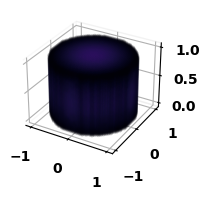

In [4]:
fig = plt.figure(figsize=(2, 2))
ax = fig.add_subplot(projection="3d")

basis_fns = ch.Psi.view(M, K, L * 2 + 1, ch.num_radii, ch.num_phi, ch.num_height)
plotting.plot_cylinder_fn(basis_fns[0, 0, 0].numpy(), ax=ax)

In [8]:
w = torch.randn(9).view(1,9)
ch(w)[0,0,0,0]

tensor(-0.1814)

In [9]:
ch(w, torch.tensor([[0.05,0.0873,0.05]]))

tensor([[[[-0.1814]]]])

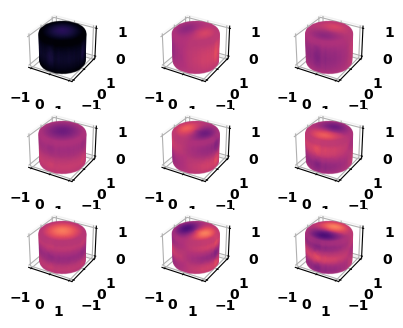

In [11]:
basis_fns = ch.Psi.view(M, K, L * 2 + 1, ch.num_radii, ch.num_phi, ch.num_height)

fig = plt.figure(figsize=(4 * L, M * K))
subfigs = fig.subfigures(K * M, L * 2 + 1)
for m in range(M):
    for k in range(K):
        for l in range(L * 2 + 1):
            ax = subfigs[m * K + k, l].add_subplot(projection="3d")
            plotting.plot_cylinder_fn(basis_fns[m, k, l].numpy(), ax=ax)

# Cylindrical Harmonics Transform

In [12]:
def f(r, phi, z):
    return r**2 + np.cos(2 * phi) - z**2 + r * np.sin(phi) * z


r = torch.linspace(0, 1, 10)
phi = torch.linspace(0, 2 * np.pi, 36)
z = torch.linspace(0, 1, 10)
y = f(r[:, None, None], phi[None, :, None], z[None, None, :])

/tmp/ipykernel_862853/2057440277.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return r**2 + np.cos(2 * phi) - z**2 + r * np.sin(phi) * z


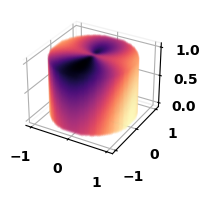

In [14]:
fig = plt.figure(figsize=(2, 2))
ax = fig.add_subplot(projection="3d")

plotting.plot_cylinder_fn(y.numpy(), ax=ax)

In [ ]:
class CHT(nn.Module):
    def __init__(self, K=1, L=3, M=1, num_radii=10, num_phi=36, num_height=10):
        super().__init__()
        self.w_lin = nn.Linear(num_radii * num_phi * num_height, M * K * (L * 2 + 1))
        self.ch = CylindricalHarmonics(K, L, M, num_radii=num_radii, num_phi=num_phi, num_height=num_height)

    def forward(self, x):
        w = self.w_lin(x)
        return self.ch(w), w.detach()

In [ ]:
K = 2
L = 3
M = 2
ch_model = CHT(K, L, M)
optimizer = torch.optim.Adam(ch_model.parameters(), lr=1e-4)

for iter in range(200):
    y_pred, _ = ch_model(y.view(1, -1))
    loss = (y_pred - y).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f"iteration: {iter} loss: {loss.item()}")

iteration: 0 loss: 1.6902285814285278
iteration: 10 loss: 0.5019515752792358
iteration: 20 loss: 0.40408676862716675
iteration: 30 loss: 0.36553576588630676
iteration: 40 loss: 0.36357882618904114
iteration: 50 loss: 0.3584080934524536
iteration: 60 loss: 0.3574998676776886
iteration: 70 loss: 0.3566429615020752
iteration: 80 loss: 0.35660043358802795
iteration: 90 loss: 0.3565216064453125
iteration: 100 loss: 0.35649412870407104
iteration: 110 loss: 0.3564939796924591
iteration: 120 loss: 0.3564911484718323
iteration: 130 loss: 0.3564901649951935
iteration: 140 loss: 0.35648995637893677
iteration: 150 loss: 0.35648980736732483
iteration: 160 loss: 0.35648971796035767
iteration: 170 loss: 0.35648971796035767
iteration: 180 loss: 0.35648971796035767
iteration: 190 loss: 0.35648971796035767


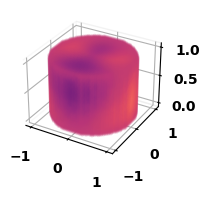

In [ ]:
fig = plt.figure(figsize=(2, 2))
ax = fig.add_subplot(projection="3d")

with torch.no_grad():
    pred, w = ch_model(y.view(1, -1))
    plotting.plot_cylinder_fn(pred.squeeze().numpy(), ax=ax)

In [ ]:
w_ph = torch.einsum("bwrpz,bw->bwrpz", ch_model.ch.Psi, w).view(
    M, K, 2 * L + 1, ch_model.ch.num_radii, ch_model.ch.num_phi, ch_model.ch.num_height
)
w.numpy().round(2)

array([[ 0.09,  0.15,  0.59,  2.04, -0.03, -0.1 , -0.02, -0.37, -0.  ,
        -0.27,  0.18,  0.01, -0.02,  0.  ,  0.53,  0.  , -0.33,  0.  ,
         0.01, -0.  ,  0.01, -0.17, -0.  ,  0.15, -0.  , -0.  ,  0.  ,
        -0.  ]], dtype=float32)

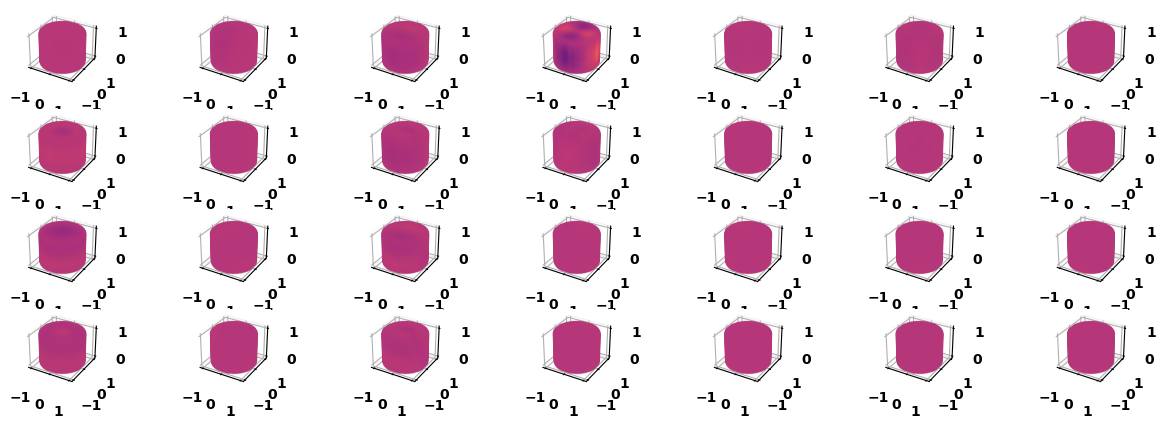

In [20]:
fig = plt.figure(figsize=(4 * L, K * M))
subfigs = fig.subfigures(K * M, L * 2 + 1)
for m in range(M):
    for k in range(K):
        for l in range(L * 2 + 1):
            ax = subfigs[m * K + k, l].add_subplot(projection="3d")
            plotting.plot_cylinder_fn(w_ph[m, k, l].numpy(), ax=ax, vmin=w_ph.min(), vmax=w_ph.max())

# 